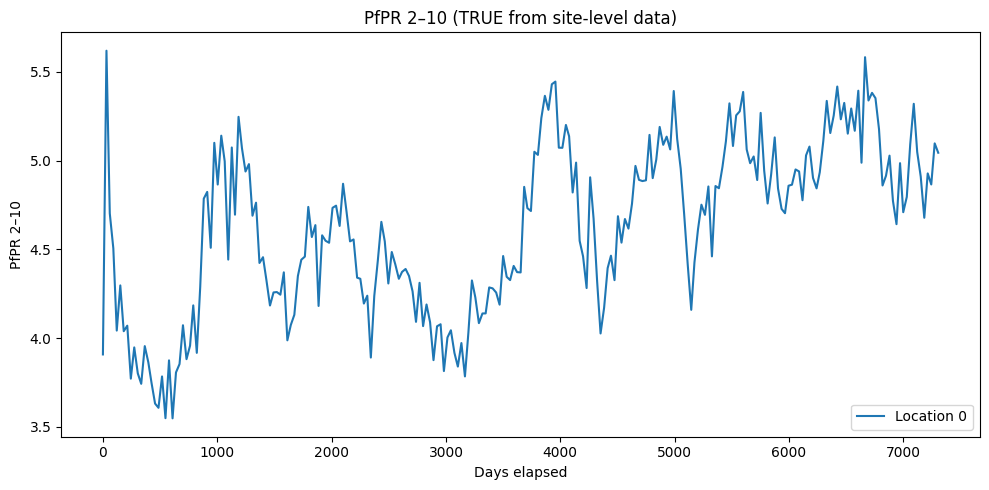

In [159]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# output_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs"
# sceario_folder = "al/control/mp_0p001983__rev_0__cost_0p0005"
# db_path = f"{output_path}/{sceario_folder}/monthly_data_0.db"
db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/as_mq/control/mp_0p01__rev_0__cost_0p0005/monthly_data_5.db"
db_path = "/Users/neo/Projects/temple/malasim/build/bin/monthly_data_0.db"

# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p005__rev_0__cost_0p0005/monthly_data_5.db"

conn = sqlite3.connect(db_path)

# -----------------------
# LOAD TRUE PfPR
# -----------------------
df = pd.read_sql_query("""
SELECT monthly_data_id, location_id, pfpr_2to10
FROM monthly_site_data_cell
""", conn)

time = pd.read_sql_query("""
SELECT id, days_elapsed
FROM monthly_data
""", conn)

df = df.merge(time, left_on="monthly_data_id", right_on="id")

# -----------------------
# AGGREGATE (no fake weighting)
# -----------------------
agg = df.groupby(["days_elapsed", "location_id"])["pfpr_2to10"].mean().reset_index()

# -----------------------
# PLOT
# -----------------------
plt.figure(figsize=(10,5))

for loc in sorted(agg["location_id"].unique()):
    sub = agg[agg["location_id"] == loc]
    plt.plot(sub["days_elapsed"], sub["pfpr_2to10"], label=f"Location {loc}")

plt.title("PfPR 2–10 (TRUE from site-level data)")
plt.xlabel("Days elapsed")
plt.ylabel("PfPR 2–10")
plt.legend()
plt.tight_layout()

plt.show()

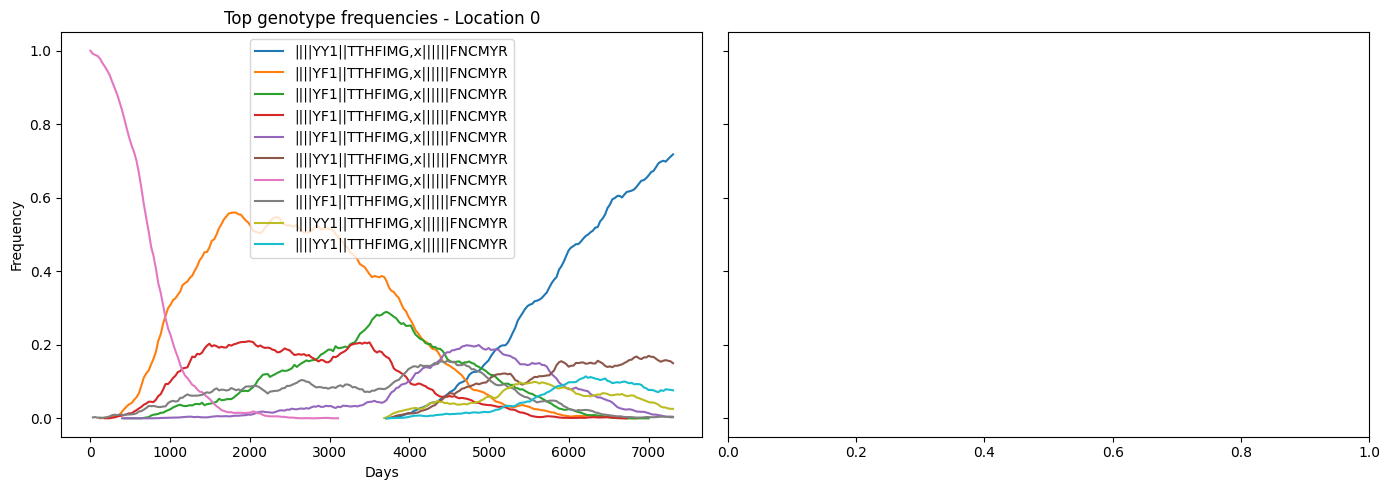

In [160]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# output_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs"
# sceario_folder = "al/control/mp_0p001983__rev_0__cost_0p0005"
# db_path = f"{output_path}/{sceario_folder}/monthly_data_1.db"
conn = sqlite3.connect(db_path)

# ----------------------------
# LOAD DATA
# ----------------------------
geno = pd.read_sql_query("""
SELECT monthly_data_id, location_id, genome_id, weighted_occurrences
FROM monthly_genome_data_cell
""", conn)

time = pd.read_sql_query("""
SELECT id, days_elapsed
FROM monthly_data
""", conn)

genotype = pd.read_sql_query("""
SELECT id, name
FROM genotype
""", conn)

# ----------------------------
# MERGE
# ----------------------------
df = geno.merge(time, left_on="monthly_data_id", right_on="id")
df = df.merge(genotype, left_on="genome_id", right_on="id")
rename_dict = {"weighted_occurrences": "occurrences"}
df = df.rename(columns=rename_dict)

# ----------------------------
# AGGREGATE RAW GENOTYPES
# ----------------------------
agg = df.groupby(["days_elapsed", "location_id", "name"])["occurrences"].sum().reset_index()

# total per time/location
agg["total"] = agg.groupby(["days_elapsed", "location_id"])["occurrences"].transform("sum")
agg["freq"] = agg["occurrences"] / agg["total"]

# ----------------------------
# PICK TOP GENOTYPES (important for readability)
# ----------------------------
top_genos = (
    agg.groupby("name")["occurrences"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

agg = agg[agg["name"].isin(top_genos)]

# ----------------------------
# PLOT
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for loc, ax in zip(sorted(agg.location_id.unique()), axes):
    sub = agg[agg.location_id == loc]

    for g in top_genos:
        s = sub[sub["name"] == g]
        ax.plot(s["days_elapsed"], s["freq"], label=g[:30])  # shorten label

    ax.set_title(f"Top genotype frequencies - Location {loc}")
    ax.set_xlabel("Days")
    ax.legend()

axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [161]:
print("Total unique genotypes:", df["name"].nunique())

print("\nTop 10 genotypes:")
print(
    df.groupby("name")["occurrences"].sum()
    .sort_values(ascending=False)
    .head(10)
)

Total unique genotypes: 20

Top 10 genotypes:
name
||||YY1||TTHFIMG,x||||||FNCMYRIPRPYIA|1    488891.434524
||||YF1||TTHFIMG,x||||||FNCMYRIPRPYRA|2    466000.995238
||||YF1||TTHFIMG,x||||||FNCMYRIPRPYIA|2    216163.805952
||||YF1||TTHFIMG,x||||||FNCMYRIPRPCIA|2    180805.719048
||||YF1||TTHFIMG,x||||||FNCMYRIPRPYIA|1    162285.144048
||||YY1||TTHFIMG,x||||||FNCMYRIPRPYRA|1    157285.960714
||||YF1||TTHFIMG,x||||||FNCMYRIPRPCRA|1    154951.861905
||||YF1||TTHFIMG,x||||||FNCMYRIPRPYRA|1    152862.139286
||||YY1||TTHFIMG,x||||||FNCMYRIPRPYIA|2     81426.782143
||||YY1||TTHFIMG,x||||||FNCMYRIPRPCIA|1     79471.945238
Name: occurrences, dtype: float64


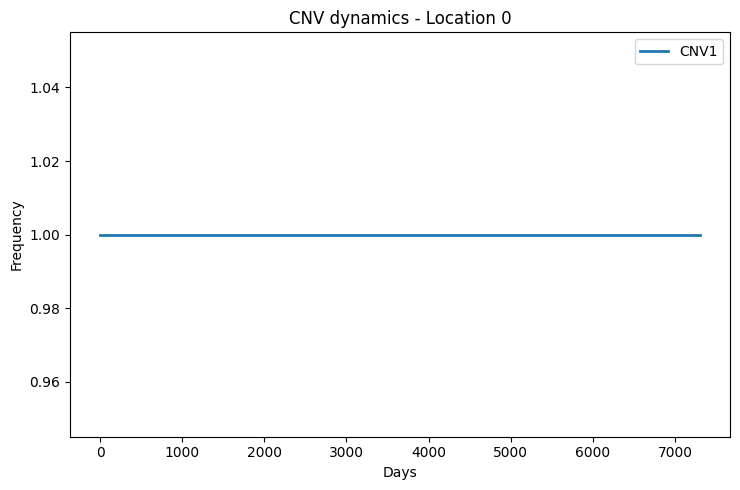

In [ ]:
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/control/mp_0p001983__rev_2__cost_0p0005/monthly_data_1.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p001983__rev_0__cost_0p005/monthly_data_0.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p01__rev_0p5__cost_0p0005/monthly_data_0.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/control/mp_0p001983__rev_0p5__cost_0p005/monthly_data_0.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/control/mp_0p001983__rev_0p2__cost_0p0005/monthly_data_0.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/as_mq/control/mp_0p001983__rev_0p5__cost_0p005/monthly_data_0.db"
# db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/control/mp_0p001983__rev_0__cost_0p005/monthly_data_0.db"

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import re


db_path = "/Users/neo/Projects/temple/experiments/cnv_reversion/outputs/as_mq/control/mp_0p001983__rev_0p05__cost_0p0005/monthly_data_0.db"
db_path = "/Users/neo/Projects/temple/malasim/build/bin/monthly_data_0.db"

conn = sqlite3.connect(db_path)

# ----------------------------
# LOAD DATA
# ----------------------------
geno = pd.read_sql_query("""
SELECT monthly_data_id, location_id, genome_id, occurrences
FROM monthly_genome_data_cell
""", conn)

time = pd.read_sql_query("""
SELECT id, days_elapsed
FROM monthly_data
""", conn)

genotype = pd.read_sql_query("""
SELECT id, name
FROM genotype
""", conn)

df = geno.merge(time, left_on="monthly_data_id", right_on="id")
df = df.merge(genotype, left_on="genome_id", right_on="id")

# ----------------------------
# EXTRACT CNV (STRICT, NO UNKNOWN)
# ----------------------------

def extract_cnv(s):
    # find the first numeric CNV in the genotype block
    # robust to ANY 2-letter prefix (NF, YF, AB, XY, etc.)

    m = re.search(r"\|\|\|\|[A-Z]{2}(\d+)\|\|", s)
    m = re.search(r"\|(\d+)$", s)

    if m:
        return "CNV" + m.group(1)

    # fallback: extract any standalone CNV digit after letters
    m2 = re.search(r"([A-Z]{2})(\d+)", s)
    if m2:
        return "CNV" + m2.group(2)

    raise ValueError(f"Cannot parse CNV from: {s}")

df["CNV"] = df["name"].apply(extract_cnv)

# ----------------------------
# AGGREGATE
# ----------------------------
agg = df.groupby(["days_elapsed", "location_id", "CNV"])["occurrences"].sum().reset_index()

agg["total"] = agg.groupby(["days_elapsed", "location_id"])["occurrences"].transform("sum")
agg["freq"] = agg["occurrences"] / agg["total"]

# ----------------------------
# PLOT
# ----------------------------

n_locations = agg["location_id"].nunique()
fig, axes = plt.subplots(1, n_locations, figsize=(7.5*n_locations,5), sharey=True)

if n_locations == 1:
    axes = [axes]

for loc, ax in zip(sorted(agg["location_id"].unique()), axes):
    sub = agg[agg["location_id"] == loc]

    for cnv in sorted(sub["CNV"].unique()):
        s = sub[sub["CNV"] == cnv]
        ax.plot(s["days_elapsed"], s["freq"], label=cnv, linewidth=2)

    ax.set_title(f"CNV dynamics - Location {loc}")
    ax.set_xlabel("Days")
    ax.legend()

axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()